In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data from CSV files
sgd_df = pd.read_csv('../../evaluation/sgd/netflow/sgd_evaluation.csv')
mlp_df = pd.read_csv("../../evaluation/mlp/netflow/mlp_evaluation.csv")
ensemble_df = pd.read_csv("../../evaluation/ensemble/netflow/ensemble_evaluation.csv")

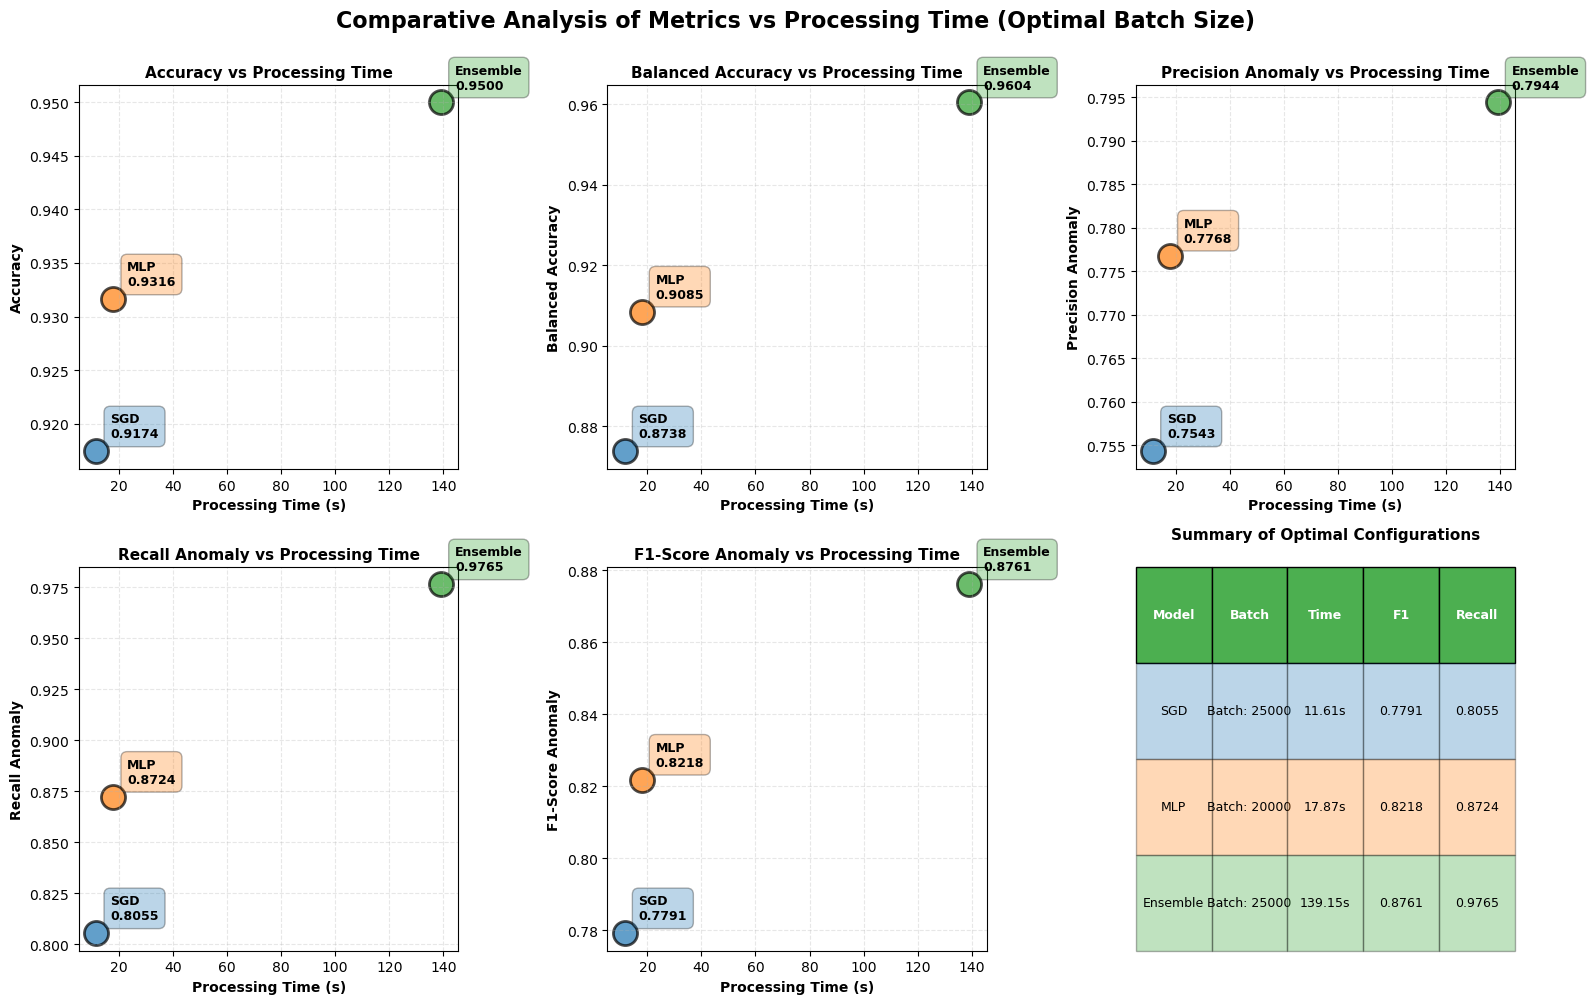


COMPARATIVE ANALYSIS OF MODELS - OPTIMAL CONFIGURATION
   Model  Batch Size  Processing Time (s)  Accuracy  Balanced Accuracy  Precision Anomaly  Recall Anomaly  F1 Anomaly
     SGD       25000                11.61    0.9174             0.8738             0.7543          0.8055      0.7791
     MLP       20000                17.87    0.9316             0.9085             0.7768          0.8724      0.8218
Ensemble       25000               139.15    0.9500             0.9604             0.7944          0.9765      0.8761

DETAILED ANALYSIS:
• SGD:      F1-score 0.7791 in 11.61s (batch 25000)
• MLP:      F1-score 0.8218 in 17.87s (batch 20000) → +0.0427 F1, +6.26s
• Ensemble: F1-score 0.8761 in 139.15s (batch 25000) → +0.0543 F1, +121.28s

TRADE-OFF ANALYSIS:
• MLP vs SGD:       53.9% slower for 5.5% better F1-score
• Ensemble vs MLP:  678.7% slower for 6.6% better F1-score


In [7]:


# Extract optimal batch configurations for each model
# SGD optimal: batch 25000
sgd_optimal = sgd_df[sgd_df['batch_size'] == 25000].iloc[0]

# MLP optimal: batch 20000
mlp_optimal = mlp_df[mlp_df['batch_size'] == 20000].iloc[0]

# Ensemble optimal: batch 25000
ensemble_optimal = ensemble_df[ensemble_df['batch_size'] == 25000].iloc[0]

# Create comparison dataframe
comparison_data = {
    'Model': ['SGD', 'MLP', 'Ensemble'],
    'Batch Size': [int(sgd_optimal['batch_size']), int(mlp_optimal['batch_size']), int(ensemble_optimal['batch_size'])],
    'Processing Time (s)': [sgd_optimal['total_time_sec'], mlp_optimal['total_time_sec'], ensemble_optimal['total_time_sec']],
    'Accuracy': [sgd_optimal['accuracy'], mlp_optimal['accuracy'], ensemble_optimal['accuracy']],
    'Balanced Accuracy': [sgd_optimal['balanced_accuracy'], mlp_optimal['balanced_accuracy'], ensemble_optimal['balanced_accuracy']],
    'Precision Anomaly': [sgd_optimal['precision_anomaly'], mlp_optimal['precision_anomaly'], ensemble_optimal['precision_anomaly']],
    'Recall Anomaly': [sgd_optimal['recall_anomaly'], mlp_optimal['recall_anomaly'], ensemble_optimal['recall_anomaly']],
    'F1 Anomaly': [sgd_optimal['f1_anomaly'], mlp_optimal['f1_anomaly'], ensemble_optimal['f1_anomaly']]
}

df = pd.DataFrame(comparison_data)

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Comparative Analysis of Metrics vs Processing Time (Optimal Batch Size)', 
             fontsize=16, fontweight='bold', y=1.00)

# Color for each model
colors = {'SGD': '#1f77b4', 'MLP': '#ff7f0e', 'Ensemble': '#2ca02c'}

# 1. Accuracy vs Processing Time
ax = axes[0, 0]
for idx, row in df.iterrows():
    ax.scatter(row['Processing Time (s)'], row['Accuracy'], s=300, 
              color=colors[row['Model']], alpha=0.7, edgecolors='black', linewidth=2)
    ax.annotate(f"{row['Model']}\n{row['Accuracy']:.4f}", 
               xy=(row['Processing Time (s)'], row['Accuracy']),
               xytext=(10, 10), textcoords='offset points', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor=colors[row['Model']], alpha=0.3))
ax.set_xlabel('Processing Time (s)', fontsize=10, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=10, fontweight='bold')
ax.set_title('Accuracy vs Processing Time', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')

# 2. Balanced Accuracy vs Processing Time
ax = axes[0, 1]
for idx, row in df.iterrows():
    ax.scatter(row['Processing Time (s)'], row['Balanced Accuracy'], s=300, 
              color=colors[row['Model']], alpha=0.7, edgecolors='black', linewidth=2)
    ax.annotate(f"{row['Model']}\n{row['Balanced Accuracy']:.4f}", 
               xy=(row['Processing Time (s)'], row['Balanced Accuracy']),
               xytext=(10, 10), textcoords='offset points', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor=colors[row['Model']], alpha=0.3))
ax.set_xlabel('Processing Time (s)', fontsize=10, fontweight='bold')
ax.set_ylabel('Balanced Accuracy', fontsize=10, fontweight='bold')
ax.set_title('Balanced Accuracy vs Processing Time', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')

# 3. Precision Anomaly vs Processing Time
ax = axes[0, 2]
for idx, row in df.iterrows():
    ax.scatter(row['Processing Time (s)'], row['Precision Anomaly'], s=300, 
              color=colors[row['Model']], alpha=0.7, edgecolors='black', linewidth=2)
    ax.annotate(f"{row['Model']}\n{row['Precision Anomaly']:.4f}", 
               xy=(row['Processing Time (s)'], row['Precision Anomaly']),
               xytext=(10, 10), textcoords='offset points', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor=colors[row['Model']], alpha=0.3))
ax.set_xlabel('Processing Time (s)', fontsize=10, fontweight='bold')
ax.set_ylabel('Precision Anomaly', fontsize=10, fontweight='bold')
ax.set_title('Precision Anomaly vs Processing Time', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')

# 4. Recall Anomaly vs Processing Time
ax = axes[1, 0]
for idx, row in df.iterrows():
    ax.scatter(row['Processing Time (s)'], row['Recall Anomaly'], s=300, 
              color=colors[row['Model']], alpha=0.7, edgecolors='black', linewidth=2)
    ax.annotate(f"{row['Model']}\n{row['Recall Anomaly']:.4f}", 
               xy=(row['Processing Time (s)'], row['Recall Anomaly']),
               xytext=(10, 10), textcoords='offset points', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor=colors[row['Model']], alpha=0.3))
ax.set_xlabel('Processing Time (s)', fontsize=10, fontweight='bold')
ax.set_ylabel('Recall Anomaly', fontsize=10, fontweight='bold')
ax.set_title('Recall Anomaly vs Processing Time', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')

# 5. F1-Score Anomaly vs Processing Time
ax = axes[1, 1]
for idx, row in df.iterrows():
    ax.scatter(row['Processing Time (s)'], row['F1 Anomaly'], s=300, 
              color=colors[row['Model']], alpha=0.7, edgecolors='black', linewidth=2)
    ax.annotate(f"{row['Model']}\n{row['F1 Anomaly']:.4f}", 
               xy=(row['Processing Time (s)'], row['F1 Anomaly']),
               xytext=(10, 10), textcoords='offset points', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor=colors[row['Model']], alpha=0.3))
ax.set_xlabel('Processing Time (s)', fontsize=10, fontweight='bold')
ax.set_ylabel('F1-Score Anomaly', fontsize=10, fontweight='bold')
ax.set_title('F1-Score Anomaly vs Processing Time', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')

# 6. Comparative table
ax = axes[1, 2]
ax.axis('tight')
ax.axis('off')

tabla_data = []
for idx, row in df.iterrows():
    tabla_data.append([
        row['Model'],
        f"Batch: {row['Batch Size']}",
        f"{row['Processing Time (s)']:.2f}s",
        f"{row['F1 Anomaly']:.4f}",
        f"{row['Recall Anomaly']:.4f}"
    ])

tabla = ax.table(cellText=tabla_data,
                colLabels=['Model', 'Batch', 'Time', 'F1', 'Recall'],
                cellLoc='center',
                loc='center',
                bbox=[0, 0, 1, 1])

tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1, 2)

# Color header
for i in range(5):
    tabla[(0, i)].set_facecolor('#4CAF50')
    tabla[(0, i)].set_text_props(weight='bold', color='white')

# Color rows according to model
for i in range(1, 4):
    modelo = tabla_data[i-1][0]
    for j in range(5):
        tabla[(i, j)].set_facecolor(colors[modelo])
        tabla[(i, j)].set_alpha(0.3)

ax.set_title('Summary of Optimal Configurations', fontsize=11, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('metrics_vs_time_comparative.png', dpi=300, bbox_inches='tight')
plt.show()

# Print table in console
print("\n" + "="*100)
print("COMPARATIVE ANALYSIS OF MODELS - OPTIMAL CONFIGURATION")
print("="*100)
print(df.to_string(index=False))
print("="*100)

# Analysis
print("\nDETAILED ANALYSIS:")
print(f"• SGD:      F1-score {df.loc[0, 'F1 Anomaly']:.4f} in {df.loc[0, 'Processing Time (s)']:.2f}s (batch {df.loc[0, 'Batch Size']})")
print(f"• MLP:      F1-score {df.loc[1, 'F1 Anomaly']:.4f} in {df.loc[1, 'Processing Time (s)']:.2f}s (batch {df.loc[1, 'Batch Size']}) → +{(df.loc[1, 'F1 Anomaly']-df.loc[0, 'F1 Anomaly']):.4f} F1, +{(df.loc[1, 'Processing Time (s)']-df.loc[0, 'Processing Time (s)']):.2f}s")
print(f"• Ensemble: F1-score {df.loc[2, 'F1 Anomaly']:.4f} in {df.loc[2, 'Processing Time (s)']:.2f}s (batch {df.loc[2, 'Batch Size']}) → +{(df.loc[2, 'F1 Anomaly']-df.loc[1, 'F1 Anomaly']):.4f} F1, +{(df.loc[2, 'Processing Time (s)']-df.loc[1, 'Processing Time (s)']):.2f}s")
print("="*100)

print("\nTRADE-OFF ANALYSIS:")
time_increase_mlp = ((df.loc[1, 'Processing Time (s)']-df.loc[0, 'Processing Time (s)'])/df.loc[0, 'Processing Time (s)']*100)
f1_increase_mlp = ((df.loc[1, 'F1 Anomaly']-df.loc[0, 'F1 Anomaly'])/df.loc[0, 'F1 Anomaly']*100)
time_increase_ensemble = ((df.loc[2, 'Processing Time (s)']-df.loc[1, 'Processing Time (s)'])/df.loc[1, 'Processing Time (s)']*100)
f1_increase_ensemble = ((df.loc[2, 'F1 Anomaly']-df.loc[1, 'F1 Anomaly'])/df.loc[1, 'F1 Anomaly']*100)

print(f"• MLP vs SGD:       {time_increase_mlp:.1f}% slower for {f1_increase_mlp:.1f}% better F1-score")
print(f"• Ensemble vs MLP:  {time_increase_ensemble:.1f}% slower for {f1_increase_ensemble:.1f}% better F1-score")
print("="*100)
